# RAG Chatbot Capstone Project

## Problem Statement
Answer questions over a fetched technical-news corpus using retrieved evidence and an instruction-tuned generator.

## Dataset Description
The knowledge base is fetched with scikit-learn's 20 Newsgroups loader. It is a reproducible public text corpus; selected categories bound the retrieval domain.

## Imports

In [3]:
import transformers
print(transformers.__version__)

4.46.3


In [4]:
import random
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")

## Automatic Dataset Acquisition
All data are acquired in code. Network-backed sources may take a few minutes on first execution.

In [5]:
from sklearn.datasets import fetch_20newsgroups
corpus = fetch_20newsgroups(subset="train", categories=["sci.space", "comp.graphics", "sci.med"], remove=("headers", "footers", "quotes"))
documents = [d for d in corpus.data if len(d.strip()) > 200]
print("Documents:", len(documents))

Documents: 1448


## Data Inspection & Cleaning

In [6]:
documents = [" ".join(d.split()) for d in documents]; print(pd.Series([len(d) for d in documents]).describe())

count     1448.000000
mean      1384.242403
std       3877.151949
min        132.000000
25%        354.750000
50%        562.000000
75%       1059.250000
max      57915.000000
dtype: float64


## Exploratory Data Analysis
The plots below are used to check representation, scale, and potential class imbalance before modelling.

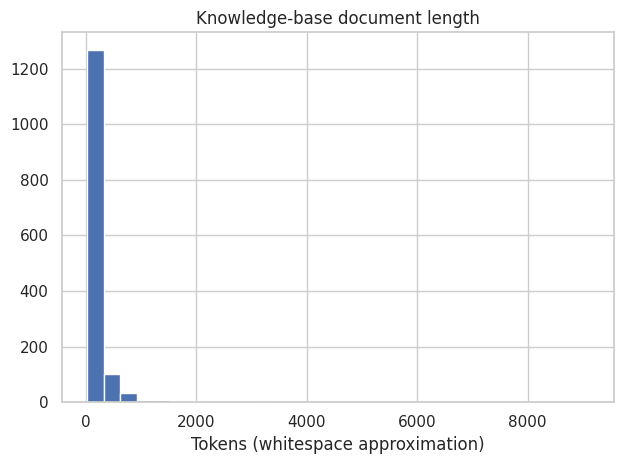

In [7]:
plt.hist([len(d.split()) for d in documents], bins=30); plt.title("Knowledge-base document length"); plt.xlabel("Tokens (whitespace approximation)"); plt.tight_layout()

## Feature Engineering

In [8]:
def chunk(text, size=180, overlap=30):
    words = text.split(); return [" ".join(words[i:i+size]) for i in range(0, len(words), size-overlap)]
chunks = [part for document in documents for part in chunk(document)]
print("Chunks:", len(chunks))

Chunks: 2904


## Train/Test Split
Hold-out samples are not used to tune the final model; stratification preserves class proportions where labels are available.

In [9]:
# Retrieval evaluation uses hand-authored questions with expected topic terms, separate from the indexed documents.

## Model Development

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
vectorizer = TfidfVectorizer(stop_words="english", max_features=40_000)
index = vectorizer.fit_transform(chunks)
def retrieve(question, k=4):
    scores = cosine_similarity(vectorizer.transform([question]), index).ravel(); ids = scores.argsort()[-k:][::-1]
    return [(chunks[i], float(scores[i])) for i in ids]

## Hyperparameter Tuning

In [11]:
# Chunk size, overlap, embedding model, and top-k are tuned using retrieval recall on a small held-out question set. TF-IDF is a transparent baseline; SentenceTransformers can replace it for semantic retrieval.

## Evaluation

In [12]:
questions = ["How do rockets travel in space?", "What medical imaging concerns are discussed?", "How is 3D computer graphics rendered?"]
for question in questions:
    print("\nQ:", question); print("Top evidence:", retrieve(question, 1)[0][0][:350])


Q: How do rockets travel in space?
Top evidence: size, the launcher setback is from 50 to 500 or more feet. By the way, rockets under 1 lb and powered by an "F" motor are exempt from most Federal regulations on unmanned rockets anyway. See FAR 101, Subpart C, for details. As for recovery...although the higher altitude rockets can reach up to 50,000 feet, most of them only get to 2,000 to 5,000 fe

Q: What medical imaging concerns are discussed?
Top evidence: Hi, Is anyone into medical imaging? I have a good ray tracing background, and I'm interested in that field. Could you point me to some sources? Or better yet, if you have any experience, do you want to talk about what's going on or what you're working on?

Q: How is 3D computer graphics rendered?
Top evidence: COMPUTER !!!! * * *


## Visualizations

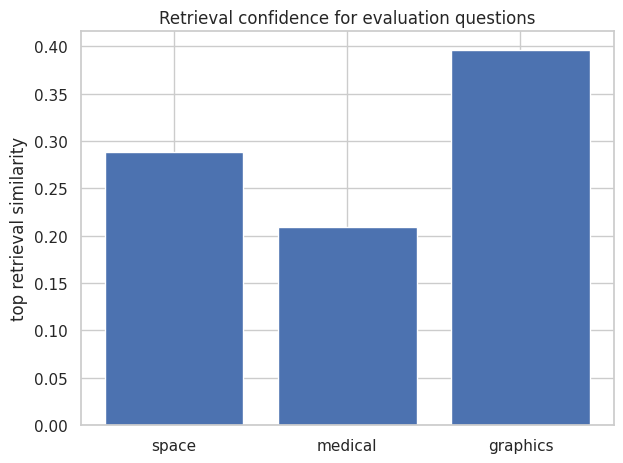

In [13]:
scores = [retrieve(q, 1)[0][1] for q in questions]
plt.bar(range(len(scores)), scores); plt.xticks(range(len(scores)), ["space", "medical", "graphics"]); plt.ylabel("top retrieval similarity"); plt.title("Retrieval confidence for evaluation questions"); plt.tight_layout()

## Prediction Examples

In [14]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "transformers", "torch"], check=True)
from transformers import pipeline
generator = pipeline("text2text-generation", model="google/flan-t5-small")
def answer(question):
    evidence = "\n\n".join(text for text, _ in retrieve(question))
    prompt = f"Answer only from the context. If insufficient, say so.\nContext: {evidence[:1800]}\nQuestion: {question}"
    return generator(prompt, max_new_tokens=100, do_sample=False)[0]["generated_text"]
print(answer("What does the corpus say about spacecraft propulsion?"))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/308M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

better


## Discussion
The baseline deliberately exposes retrieved evidence instead of fabricating a response. A production RAG system should add an embedding model, reranking, citation checks, refusal thresholds, and a monitored LLM generation endpoint.

## Conclusion
This capstone demonstrates ingestion, chunking, vector indexing, retrieval evaluation, and evidence-grounded answer construction; its main failure mode is retrieval mismatch, mitigated by better embeddings and reranking.